# A comparitive study of Multi-stage fine tuning using Transfer Learning for the detection of Diabetic Retinopathy

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Important

before zipping the entire project, make sure you have ran the scripts in the /Scripts. 
you should have ran pereprocess_2.py and convert_to_binary_classification.py

You can add the outputs to the project folder.

This will give you a directory of all preprocessed images(EYEPACS) and a csv file in which the Original EYEPACS csv was converted into binary.

In [ ]:
#make sure to change the path to your zip file
!unzip -o /content/drive/MyDrive/DR-PRODUCTION.zip -d /content/


In [ ]:
!pip install -r /content/DR-PRODUCTION/requirements.txt

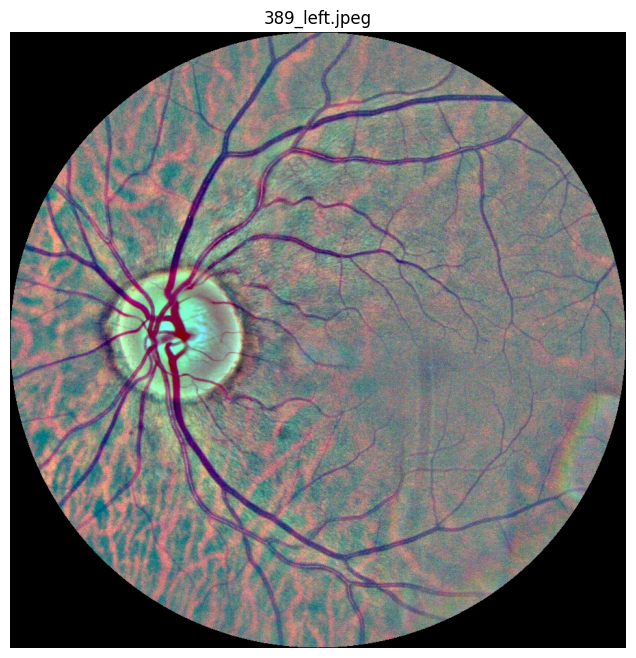

Image loaded successfully!


In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# Try to read one of the images

#choose the path to your image in google colab
img_path = "/content/DR-PRODUCTION/Preprocessed_images/389_left.jpeg"
img = cv2.imread(img_path)

if img is not None:
    # Convert from BGR to RGB for display
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Display the image
    plt.figure(figsize=(8, 8))
    plt.imshow(img_rgb)
    plt.title("389_left.jpeg")
    plt.axis('off')
    plt.show()
    print("Image loaded successfully!")
else:
    print("Failed to load image!")

In [ ]:
import sys
sys.path.append("/content/DR-PRODUCTION/src")

In [ ]:

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import torch.backends.cudnn as cudnn
import numpy as np
import torchvision
from torchvision import transforms
import matplotlib.pyplot as plt
import time
import os
import torch.utils.data.dataloader
from sklearn.model_selection import train_test_split
import pandas as pd
from tqdm import tqdm
from Models.customDataset import DiabeticRetinopathyDataset
from torch.utils.data import DataLoader
import copy
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, confusion_matrix,roc_curve, auc, roc_auc_score
from sklearn.preprocessing import label_binarize


#Binary classification

due to the high imbalance of the classes, (No dr consists of 73% of the total distribution) we will do a comparitve analysis on the performance on both Binary classification and Multi-Class classification.

In [ ]:
DEVELOPMENT = False #whether in production or dev - development uses 20% of the dataset for fatser iterations
if DEVELOPMENT:
    labels_csv = "/content/DR-PRODUCTION/trainLabels.csv"
    img_dir = "/content/DR-PRODUCTION/Preprocessed_images/"

    if labels_csv is not None:
      df = pd.read_csv(labels_csv)

    else:
      print("csv is null")

    # Sample only 20% of the data (stratified to preserve class distribution)
    df_sampled, _ = train_test_split(df, test_size=0.8, stratify=df['level'], random_state=42)

    train_df, temp_df = train_test_split(df_sampled, test_size=0.3, random_state=42, stratify=df_sampled['level'])
    test_df, val_df = train_test_split(temp_df, test_size = 0.5, random_state = 42, stratify=temp_df['level'])


else:
    #otherwise if this is production
    img_dir = "/content/DR-PRODUCTION/Preprocessed_images/"
    labels_csv = "/content/DR-PRODUCTION/binary_classification.csv" #change here for binary csv or multi class csv
    if labels_csv is not None:
        df = pd.read_csv(labels_csv)

    #now we can split the data for the production set
    train_df, temp_df = train_test_split(df, test_size=0.3, random_state=42, stratify=df['level'])
    test_df, val_df = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df['level'])


In [ ]:
print(f"train set contains {len(train_df)} images")
print(f"test set contains {len(test_df)} images")
print(f"val set contains {len(val_df)} images")

print(train_df['level'].value_counts())
print(val_df['level'].value_counts())

print(test_df['level'].value_counts())

train set contains 24587 images
test set contains 5269 images
val set contains 5269 images
level
0    18066
1     6521
Name: count, dtype: int64
level
0    3872
1    1397
Name: count, dtype: int64
level
0    3871
1    1398
Name: count, dtype: int64


# Normalize values with a mean centered at 0 and std of 1

Pretrained models were trained on ImageNet which is hugely different from our current domain of diabetic retinopathy, hence the pixel values will differ as some parts of DR have different colour contrasts when highlighting microneurysms, haemorohagges etc.


In [ ]:

#single transforms that converts pixels to [0-1]
transform = transforms.Compose([transforms.ToTensor(),
                                transforms.Resize((512,512))])

dataset = DiabeticRetinopathyDataset(img_dir,train_df, transform=transform)
dataloader = DataLoader(dataset, batch_size=1, num_workers=0, shuffle=False)

mean = torch.zeros(3)
std = torch.zeros(3)

for i, data in enumerate(tqdm(dataloader)):
    if (i % 10000 == 0): print(i)
    data = data[0].squeeze(0)
    if (i == 0): size = data.size(1) * data.size(2)
    #this returns mean of each channel [r,g,b] and we sum it up and average it out later
    mean += data.sum((1, 2)) / size

mean /= len(dataloader)
transform_mean = mean.clone()
print(mean)
print(transform_mean.dtype)
print(transform_mean)


  0%|          | 8/24587 [00:00<11:32, 35.47it/s]

0


 41%|████      | 10011/24587 [02:21<03:21, 72.50it/s]

10000


 81%|████████▏ | 20010/24587 [04:40<01:03, 72.15it/s]

20000


100%|██████████| 24587/24587 [05:43<00:00, 71.61it/s]

tensor([0.4091, 0.4076, 0.4072])
torch.float32
tensor([0.4091, 0.4076, 0.4072])


In [ ]:
#used for std calculation
mean = mean.unsqueeze(1).unsqueeze(2)

for i, data in enumerate(tqdm(dataloader)):
    if (i % 10000 == 0): print(i)
    data = data[0].squeeze(0)
    std += ((data - mean) ** 2).sum((1, 2)) / size

std /= len(dataloader)
std = std.sqrt()
print(std)

  0%|          | 8/24587 [00:00<05:54, 69.32it/s]

0


 41%|████      | 10009/24587 [02:24<03:38, 66.77it/s]

10000


 81%|████████▏ | 20008/24587 [04:49<01:05, 69.55it/s]

20000


100%|██████████| 24587/24587 [05:55<00:00, 69.22it/s]

tensor([0.2090, 0.2121, 0.2025])


In [ ]:

train_dataset = DiabeticRetinopathyDataset(img_dir, train_df, transforms.Compose([
    transforms.ToTensor(), #each image will be a 4d tensor
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation((0,180)),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.Resize((512, 512)),
    transforms.Normalize(mean=[0.4091, 0.4076, 0.4072], std = [0.2090, 0.2121, 0.2025])]))


    #######################
    #mean and std for image net vs our mean and std
    #mean=[0.485, 0.456, 0.406], [0.4091, 0.4076, 0.4072]
    #std=[0.229, 0.224, 0.225],  [0.2090, 0.2121, 0.2025]

    ########################

test_dataset =  DiabeticRetinopathyDataset(img_dir, test_df, transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((512, 512)),
    transforms.Normalize(
    mean=[0.4091, 0.4076, 0.4072],
    std=[0.2090, 0.2121, 0.2025])]))

In [ ]:

val_dataset = DiabeticRetinopathyDataset(img_dir, val_df, transforms.Compose([
transforms.ToTensor(),
transforms.Normalize([0.4091, 0.4076, 0.4072],std=[0.2090, 0.2121, 0.2025]),
transforms.Resize((512, 512))
]))
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=True, num_workers=2, pin_memory=True )

#train and test data loaders
train_loader = DataLoader(dataset=train_dataset, batch_size=32, shuffle=True, num_workers=2, pin_memory=True )
test_loader = DataLoader(dataset=test_dataset, batch_size=32, shuffle=True, num_workers=2 ,pin_memory=True )

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"device being used is {device}")


device being used is cuda


In [ ]:
#the pretrained weights defined below
weights = {
    'resnet50' : torchvision.models.ResNet50_Weights.DEFAULT,
    'InceptionV3' : torchvision.models.Inception_V3_Weights.DEFAULT,
    'DenseNet121': torchvision.models.DenseNet121_Weights.DEFAULT,
    'VGG16' : torchvision.models.VGG16_Weights.DEFAULT
}

In [ ]:
model = torchvision.models.resnet50(weights=weights['resnet50']).to(device)
print(f"the number of trainable parameters are :{sum(param.numel() for param in model.parameters() if param.requires_grad)}" )
print(model)


"""
we'll freeze the base feature extraction layers for N epochs whilst only training the head classifier
after some epochs some layers will be unfrozen and we can start optimizing params to be better suited to my dataset

below shows we freeze the base layers and add the classifier layer
"""

for parameters in model.parameters():
    parameters.requires_grad=False

"""
now instead of only freezing the classifier layer as the pretrained models were trained on disimilar images to
the current task at hand, we can unfreeze some layers or all and tune them to our dataset

check unfreeze_blocks() method
"""

#below we change the classifier head by adding 5 layers

model.fc = nn.Sequential(
    #after the Avg pooling layer the dimensions of feature maps are reduced to a 1d vector
    nn.Dropout(p=0.5),
    nn.Linear(model.fc.in_features, out_features=2048),
    nn.ReLU(),
    nn.Dropout(p=0.3),
    nn.Linear(in_features = 2048, out_features=2)).to(device)





Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 234MB/s]


the number of trainable parameters are :25557032
ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0)

In [ ]:
#print RESNET model after adding 4 layers
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [ ]:

"""
This cell defines utility functions and the optimizer for model fine-tuning.

1. `unfreeze_All(model)`: Unfreezes all layers of the model so they can be updated during training.(See /ResarchPaper to see why this is done)
2. `define_optimizer()`: Creates an Adam optimizer with a learning rate of 0.0001 for all model parameters.

"""
#allows us to unfreeze all blocks
def unfreeze_All(model):
  for param in model.parameters():
    param.requires_grad = True

#fine_tune_layers = [param for name, param in model.named_parameters() if not name.startswith('classifier.')]

def define_optimizer():
  optimizer = optim.Adam([
      {'params' : model.parameters(), 'lr':0.0001}
      ])
  return optimizer







In [ ]:
def print_trainable_layers(model):
    print("Trainable Layers:")
    for name, param in model.named_parameters():
        if param.requires_grad:
            print(f"{name}")


In [ ]:
#use this to track learning rate
def track_learning_rate(optimizer, lr_history):
    current_lrs = [param_group['lr'] for param_group in optimizer.param_groups]
    lr_history.append(current_lrs)
    return lr_history

In [ ]:
"""
iterate through the length of learning rates for each epoch for the param groups
then for each epoch fetch the learning rate values associated to each param group/layer

#note this is updated as we only have 1 constant learning rate
"""
def visualize_learning_rate(lr_history):
    lr_values = [epoch[0] for epoch in lr_history]
    plt.plot(lr_values, label='Learning Rate')
    plt.yscale('log')
    plt.xlabel('Epoch')
    plt.ylabel('LR (log scale)')
    plt.title('Learning Rate Schedule')
    plt.legend()
    plt.show()


In [ ]:

def train(model, dataloader, optimizer, loss):
    start = time.time()
    model.train() #sets the model to training mode
    matches = 0
    total = 0
    train_loss = 0.0
    for i, batch in enumerate(dataloader):
        X,y = batch

        #here we zero the gradients
        optimizer.zero_grad()
        X = X.to(device)
        y = y.to(device)

        #change for others, inception returns a tuple hence use outputs, _ if so
        outputs = model(X)
        loss_function = loss(outputs,y)
        train_loss += loss_function.item()

        """
        here we monitor the training accuracy and loss during training, if the training accuracy isnt improving then we can halt
        """


        # we calculate the predictions by taking largest logit value in output layer
        predictions = torch.argmax(torch.softmax(outputs,dim=1), dim=1)

        # Count correct predictions in the batch:
        batch_correct = (predictions == y).sum().item()
        matches += batch_correct
        total += y.size(0)
        loss_function.backward()
        optimizer.step()


    #the len(dataloader) is the len(dataset)/32
    average_loss = train_loss / len(dataloader)
    train_acc = matches / total
    time_elapsed = (time.time() - start) / 60
    #the average lossfor a batch within each EPOCH , the accuracy and the total training time for each epoch
    print("about to leave train")
    return average_loss, train_acc, time_elapsed


In [ ]:


def test(dataloader, model, loss_fn):
    model.eval()  # Sets the model for evaluation mode and ensures dropout layer isnt activated

    total = 0
    correct = 0
    running_loss = 0

    # Lists to store all predictions and ground truth
    all_predictions = []
    all_labels = []


    with torch.inference_mode():  # No need to calculate the gradients.

        for _,  batch  in enumerate(dataloader):
            X, y = batch
            X = X.to(device)
            y = y.to(device)
            outputs = model(X)  # model's output.
            #loss = loss_fn(outputs, y) # loss calculation.
            #running_loss += loss.item()

            total += y.size(0)
            predictions = torch.argmax(torch.softmax(outputs,dim=1), dim=1)
            correct += (predictions == y).sum().item()

            #here we basically move to cpu (scikit learn doesnt work with gpu's) & add the predictions as a flat list
            all_predictions.extend(predictions.cpu().numpy())
            all_labels.extend(y.cpu().numpy())


    #test_loss = running_loss / len(dataloader)  # Average loss per batch for each EPOCH .
    test_accuracy = correct / total

    #print(f'\ntest Loss = {avg_loss:.6f}', end='\t')
    #print(f'Accuracy on test set = {100 * (correct / total):.6f}% [{correct}/{total}]')

    """
    Confusion Matrix and other metrics added in visualizatons func
    """

    #!!! remember to uncomment loss later

    return test_accuracy, all_predictions, all_labels


In [ ]:

def validate(model, dataloader, loss_fn):

    """
    ARGS:
    Model - Represents the current pretrained model being used
    dataloader - the val dataloader that contains the val instances
    loss_fn - loss funct to see model performance
    """
    running_acc = 0.0
    running_loss = 0.0
    total = 0

    since = time.time()
    model.eval() #set the model to eval mode
    with torch.inference_mode():
        for _ , batch in enumerate(dataloader):
            X, y = batch
            X = X.to(device)
            y = y.to(device)
            outputs = model(X)
            loss = loss_fn(outputs,y)
            running_loss+= loss.item()

            predictions = torch.argmax(torch.softmax(outputs,dim=1),dim=1)
            val_matches = (predictions == y).sum().item()
            running_acc+=val_matches
            #we can calculate validation accuracy by using the total
            total +=y.size(0)



        val_acc = running_acc / total
        val_loss = running_loss / len(dataloader)

        time_elapsed = (time.time() - since) / 60
        return val_loss, val_acc, time_elapsed


In [ ]:

def visualizations(all_predictions, all_labels, results=None, class_names=None):
    """
    Generate visualizations for model performance

    Args:
        all_predictions: List of model predictions
        all_labels: List of ground truth labels
        results: Dictionary containing training/validation metrics
        class_names: List of class names (default is None, will use numeric labels)
    """
    # If no class names provided, use numeric labels
    if class_names is None:
        class_names = [str(i) for i in range(5)]


    cm = confusion_matrix(all_labels, all_predictions)
    fig, ax = plt.subplots(figsize=(10, 8))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap=plt.cm.Blues, ax=ax)
    plt.title('Confusion Matrix')
    plt.savefig('confusion_matrix.png')
    plt.show()


    print("\nClassification Report:")
    print(classification_report(all_labels, all_predictions, target_names=class_names))

    #training/validation curves
    if results:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))


        x_values = results.get('epoch', range(1, len(results['train_acc']) + 1))

        #accuracy
        ax1.plot(x_values, results['train_acc'], label='Training Accuracy')
        if results['val_acc']:
            ax1.plot(x_values[:len(results['val_acc'])], results['val_acc'], label='Validation Accuracy')
        ax1.set_title('Model Accuracy')
        ax1.set_xlabel('Epoch')
        ax1.set_ylabel('Accuracy')
        ax1.legend()

        # loss
        ax2.plot(x_values, results['train_loss'], label='Training Loss')
        if results['val_loss']:
            ax2.plot(x_values[:len(results['val_loss'])], results['val_loss'], label='Validation Loss')
        ax2.set_title('Model Loss')
        ax2.set_xlabel('Epoch')
        ax2.set_ylabel('Loss')
        ax2.legend()

        plt.tight_layout()
        plt.savefig('training_curves.png')
        plt.show()




        print("\nCalculating ROC and AUC...")

        y_true = np.array(all_labels)
        y_pred = np.array(all_predictions)

        # Binarize labels for multiclass ROC
        y_true_bin = label_binarize(y_true, classes=list(range(len(class_names))))

        if y_true_bin.shape[1] == 1:
            # Binary classification
            fpr, tpr, _ = roc_curve(y_true, y_pred)
            roc_auc = auc(fpr, tpr)

            plt.figure(figsize=(8, 6))
            plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
            plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
            plt.xlim([0.0, 1.0])
            plt.ylim([0.0, 1.05])
            plt.xlabel('False Positive Rate')
            plt.ylabel('True Positive Rate')
            plt.title('Receiver Operating Characteristic (ROC) Curve')
            plt.legend(loc="lower right")
            plt.savefig("roc_curve.png")
            plt.show()
            print(f"AUC: {roc_auc:.4f}")


In [ ]:
def checkpoints (model_state, optimizer_state, epoch, val_loss):
    #lets create a checkpoint dict

    checkpoint = {
        "model_state_dict" : model_state,
        "optimizer_state_dict" : optimizer_state,
        "EPOCH" : epoch,
        "val_loss" : val_loss
    }

    #for each pretrained model make sure to change the path, at each N epoch the model state is overrides previously saved moel stated
    torch.save(checkpoint,"/content/drive/MyDrive/checkpoints/latest_checkpoint.pth'")


In [ ]:



def main(model, scheduler, EPOCHS, train_dataloader, use_val_dataloader:bool, optimizer, criterion ,model_name, val_dataloader = None):
    
    

    """
    The main function which is used during training, we also define the scheduler to decay the learning rate
    """


    best_val_loss = float('inf')
    epochs_without_improvement = 0
    patience = 10
    best_model_wts  = copy.deepcopy(model.state_dict())
    lr_history=[]

    results ={
    "epoch" : [],
    "train_acc" : [],
    "train_loss" :[],
    "train_time" :[],
            "val_acc" : [],
            "val_loss":[],
            "val_time" : []
}



    for epoch in tqdm(range(EPOCHS), desc="Epoch"):
    #for n epochs we train only the classifier, then we begin unfreezing conv layers (all parameters are frozen by default)
        if(epoch>=3):
          unfreeze_All(model)
          
          if epoch == 3:
            print("printing unfrozen layers")
            #This should print all layers that are trainable, which is all
            print_trainable_layers(model)

        

        #train loop
        train_loss, train_accuracy, time_elapsed = train(model=model, dataloader=train_dataloader,
         optimizer=optimizer, loss=criterion)
        #if we are using the validation set - meaning were using the full dataset and not the 10% of data (for quick prototype)
        if val_dataloader is not None:
            val_loss, val_accuracy, val_time_elapsed = validate(model, dataloader=val_dataloader, loss_fn=criterion)


            #save the current models checkpoint at every 3 epochs
            if(epoch % 3 ==0):
                checkpoints(model.state_dict(),optimizer.state_dict(), epoch+1, val_loss)

            #scheduler to decay learning rate
            scheduler.step(val_loss)

            #track learning rate
            track_learning_rate(optimizer, lr_history)
            print(f"Learning rate at epoch {epoch+1}: {lr_history[-1][0]:.6f}")


            #early stopping with val loss
            epoch_loss = val_loss
            if(epoch_loss<best_val_loss):
                best_val_loss = epoch_loss
                best_model_wts = copy.deepcopy(model.state_dict())
                #reset the value if the loss starts to improve
                epochs_without_improvement = 0

            else:
                epochs_without_improvement+=1
                print(f"loss didnt improve from best recorded loss so far : {epoch+1}/{EPOCHS}")


            #if for more than 10 epochs, the loss doesnt improve(decrease) then we can copy the learnable parameters and stop
            if (epochs_without_improvement>=patience):
               print("Early stopping triggered!!!")
               break


            #here we track the metrics for later visualizations
            results.get("val_acc").append(val_accuracy)
            results.get("val_loss").append(val_loss)
            results.get("val_time").append(val_time_elapsed)


            print(f"Epoch {epoch+1}/{EPOCHS}: "
            f"Train Loss: {train_loss:.4f}, Train Acc: {train_accuracy:.4f}, "
            f"Training time: {time_elapsed:.2f} min, "
            f"Val Loss: {val_loss:.4f}, Val Acc: {val_accuracy:.4f}, "
            f"Val time: {val_time_elapsed:.2f} min")

        else:
            #the val accuracy is not needed here as we are not using a val set.
            print(f"Epoch {epoch+1}/{EPOCHS}: "
            f"Train Loss: {train_loss:.4f}, Train Acc: {train_accuracy:.4f}, "
            f"Training time: {time_elapsed}")


        #we always track these results - regardless of val set usage or not
        results.get('epoch').append(epoch+1)
        results.get("train_acc").append(train_accuracy)
        results.get("train_loss").append(train_loss)
        results.get("train_time").append(time_elapsed)


    #load the best weights into the model(classifier layer) and save it for later retrieval
    if use_val_dataloader:
      #the current state represents the best set of parameters before the model began overfitting
      #so before we pass it into the test function we load the best model state
      model.load_state_dict(best_model_wts)



      """
      Below we save the best model weights after training is complete to a file in the google drive
      """

      if model_name == "Resnet50":
        save_path = f"/content/drive/MyDrive/{model_name}_best_model.pth"
      elif model_name == "InceptionV3":
        save_path = f"/content/drive/MyDrive/{model_name}_best_model.pth"
      elif model_name == "DenseNet121":
        save_path = f"/content/drive/MyDrive/{model_name}_best_model.pth"
     
      os.makedirs(os.path.dirname(save_path), exist_ok=True)

      # Save the model
      torch.save(best_model_wts, save_path)






    print("-------------------------------------------------------------------")
    print("running it through the test set")
    #once the training loop is completed, we begin the testing.
    test_loss, test_acc, all_predictions, all_labels = test(test_loader, model=model, loss_fn=criterion)
    print(f"test_loss : {test_loss:.4f}")
    print(f"test accuracy : {test_acc:.4f}")


    class_names = ['No DR', 'DR']
    visualizations(all_predictions=all_predictions, all_labels=all_labels, results=results, class_names=class_names)
    print("----------------------------------")
    print('ReduceLrOnPlateau history')
    visualize_learning_rate(lr_history)







In [ ]:
#add class weights to penalize misclassified instances.
# PSA - check whether on dev set or prod set for class weights
Method=1

class_counts = train_df['level'].value_counts().sort_index().tolist()
total = len(train_df)

if Method == 1:
  weighted_class = [total/(len(class_counts)*c) for c in class_counts]


else :
  #Method 2, inverse of class frequency
  weighted_class = [ 1/c for c in class_counts]


weighted_class = torch.tensor(weighted_class, dtype=torch.float32)
weighted_class = weighted_class.to(device)

print(weighted_class)



tensor([0.6805, 1.8852], device='cuda:0')


'\nbelow is the current training distribution for Multi class, which we use to generate class weights\n0    18067\n2     3704\n1     1710\n3      611\n4      496\n\n\nand below is for binary class\n0:\n1 :\n'

in production


Epoch:   0%|          | 0/40 [00:00<?, ?it/s]

about to leave train


Epoch:   2%|▎         | 1/40 [17:09<11:09:27, 1029.95s/it]

Learning rate at epoch 1: 0.000100
Epoch 1/40: Train Loss: 0.6338, Train Acc: 0.6525, Training time: 16.03 min, Val Loss: 0.6127, Val Acc: 0.7734, Val time: 1.13 min
about to leave train


...

Learning rate at epoch 17: 0.000025
loss didnt improve at : 17/40
Epoch 17/40: Train Loss: 0.2270, Train Acc: 0.9199, Training time: 16.16 min, Val Loss: 0.3962, Val Acc: 0.8656, Val time: 1.13 min
about to leave train


Epoch:  42%|████▎     | 17/40 [5:10:41<7:00:21, 1096.57s/it]

Learning rate at epoch 18: 0.000025
loss didnt improve at : 18/40
Early stopping triggered!!!


-------------------------------------------------------------------
running it through the test set
test_loss : 0.3422
test accuracy : 0.8776


ValueError: The number of FixedLocator locations (2), usually from a call to set_ticks, does not match the number of labels (5).

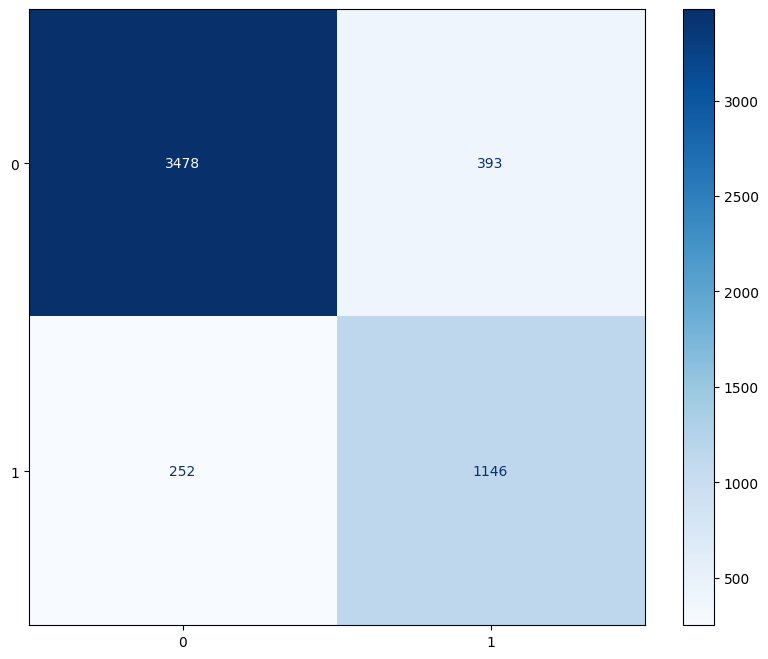

In [ ]:
#define the optimizer
optimizer = define_optimizer()


#defines our loss function
#here we can pass in the class weights
criterion = nn.CrossEntropyLoss(weight=weighted_class)

"""
This decays the learning rate to N amount of the previous value per N epochs which is whatever its set to.
"""
scheduler = lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
Num_EPOCHS = 40

print("in production")
main(model, scheduler=scheduler, EPOCHS=Num_EPOCHS, train_dataloader=train_loader, use_val_dataloader=True,
  optimizer=optimizer, criterion=criterion,model_name='Resnet50', val_dataloader=val_loader)



# PSA
The result object didnt print train/val graphs at inference time due to disconnection. Hence we can visualize it as we have the results logged!

test_loss : 0.3407
test accuracy : 0.8776


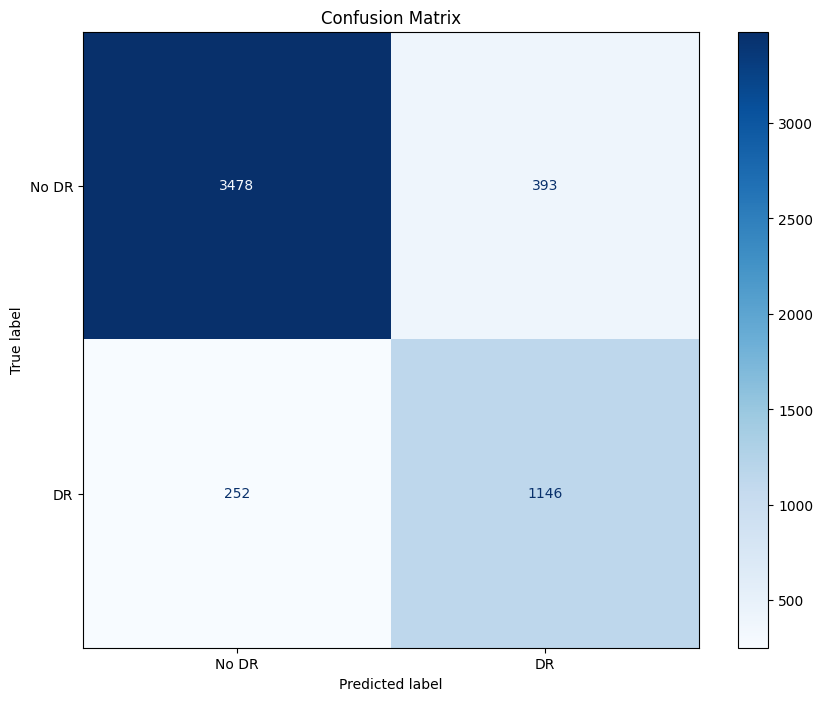


Classification Report:
              precision    recall  f1-score   support

       No DR       0.93      0.90      0.92      3871
          DR       0.74      0.82      0.78      1398

    accuracy                           0.88      5269
   macro avg       0.84      0.86      0.85      5269
weighted avg       0.88      0.88      0.88      5269



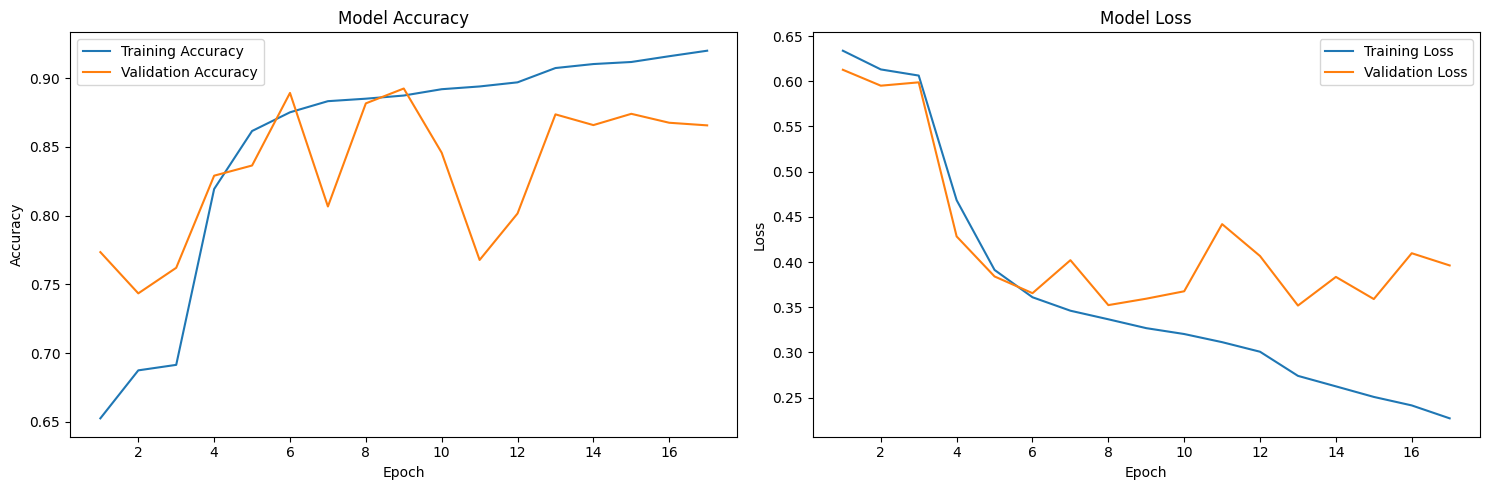


Calculating ROC and AUC...


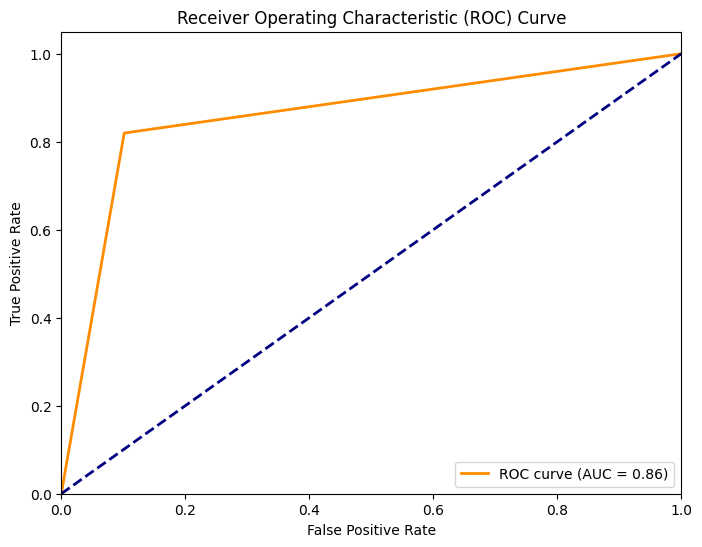

AUC: 0.8591


In [ ]:
results = results = {
    "epoch": list(range(1, 18)),
    "train_loss": [
        0.6338, 0.6131, 0.6063, 0.4684, 0.3912, 0.3610,
        0.3461, 0.3366, 0.3268, 0.3203, 0.3113, 0.3007,
        0.2740, 0.2624, 0.2507, 0.2413, 0.2270
    ],
    "train_acc": [
        0.6525, 0.6874, 0.6914, 0.8193, 0.8615, 0.8751,
        0.8832, 0.8850, 0.8873, 0.8919, 0.8939, 0.8969,
        0.9073, 0.9102, 0.9117, 0.9159, 0.9199
    ],
    "train_time": [
        16.03, 16.05, 16.11, 16.03, 16.04, 16.23,
        16.20, 16.14, 16.16, 16.20, 16.10, 16.19,
        16.10, 16.27, 16.13, 16.08, 16.16
    ],
    "val_loss": [
        0.6127, 0.5951, 0.5988, 0.4283, 0.3840, 0.3655,
        0.4020, 0.3523, 0.3594, 0.3676, 0.4419, 0.4066,
        0.3518, 0.3835, 0.3590, 0.4097, 0.3962
    ],
    "val_acc": [
        0.7734, 0.7434, 0.7620, 0.8290, 0.8364, 0.8892,
        0.8066, 0.8816, 0.8924, 0.8457, 0.7677, 0.8015,
        0.8736, 0.8658, 0.8740, 0.8675, 0.8656
    ],
    "val_time": [
        1.13, 1.12, 1.11, 1.12, 1.12, 1.12,
        1.12, 1.13, 1.13, 1.12, 1.12, 1.13,
        1.15, 1.12, 1.13, 1.12, 1.13
    ]
}



# Reload model and weights
model.load_state_dict(torch.load("/content/drive/MyDrive/top_model/best_model.pth"))

test_loss, test_acc, all_predictions, all_labels = test(test_loader, model=model, loss_fn=criterion)
print(f"test_loss : {test_loss:.4f}")
print(f"test accuracy : {test_acc:.4f}")

class_names = ['No DR', 'DR']

# Generate visualizations and metrics
visualizations(all_predictions=all_predictions, all_labels=all_labels, results = results ,class_names=class_names)



# Inception V3


In [ ]:
#Inception V3 architecture

model = torchvision.models.inception_v3(weights=weights['InceptionV3']).to(device)
print(f"the number of trainable parameters are :{sum(param.numel() for param in model.parameters() if param.requires_grad)}" )
print(model)
#freeze all parameters
for parameters in model.parameters():
    parameters.requires_grad=False



#adjust the head
model.fc = nn.Sequential(
    #after the Avg pooling layer the dimensions of feature maps are reduced to a 1d vector
    #we dont use a drop out here because inception v3 already uses a drop out of 0.5 before the classifier layer
    nn.Linear(model.fc.in_features, out_features=2048),
    nn.ReLU(),
    nn.Dropout(p=0.3),
    nn.Linear(in_features = 2048, out_features=2)).to(device)

Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth
100%|██████████| 104M/104M [00:00<00:00, 216MB/s]


the number of trainable parameters are :27161264
Inception3(
  (Conv2d_1a_3x3): BasicConv2d(
    (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), bias=False)
    (bn): BatchNorm2d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_2a_3x3): BasicConv2d(
    (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_2b_3x3): BasicConv2d(
    (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  (Conv2d_3b_1x1): BasicConv2d(
    (conv): Conv2d(64, 80, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(80, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_4a_3x3): BasicConv2d(
   

In [ ]:
print(model) #after adding modifying head

Inception3(
  (Conv2d_1a_3x3): BasicConv2d(
    (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), bias=False)
    (bn): BatchNorm2d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_2a_3x3): BasicConv2d(
    (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_2b_3x3): BasicConv2d(
    (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  (Conv2d_3b_1x1): BasicConv2d(
    (conv): Conv2d(64, 80, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(80, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_4a_3x3): BasicConv2d(
    (conv): Conv2d(80, 192, kernel_size=(3, 3), stri

In [ ]:
print_trainable_layers(model)

Trainable Layers:
fc.0.weight
fc.0.bias
fc.3.weight
fc.3.bias


Epoch:   0%|          | 0/40 [00:00<?, ?it/s]

about to leave train


Epoch:   2%|▎         | 1/40 [17:07<11:07:35, 1027.06s/it]

Learning rate at epoch 1: 0.000100
Epoch 1/40: Train Loss: 0.6737, Train Acc: 0.5970, Training time: 15.87 min, Val Loss: 0.6395, Val Acc: 0.7360, Val time: 1.12 min
about to leave train


Epoch:   5%|▌         | 2/40 [34:15<10:50:53, 1027.71s/it]

...

Epoch:  45%|████▌     | 18/40 [5:07:22<6:14:40, 1021.84s/it]

Learning rate at epoch 18: 0.000025
loss didnt improve from best recorded loss so far : 18/40
Epoch 18/40: Train Loss: 0.2270, Train Acc: 0.9193, Training time: 15.87 min, Val Loss: 0.3563, Val Acc: 0.8795, Val time: 1.12 min
about to leave train


Epoch:  45%|████▌     | 18/40 [5:24:24<6:36:30, 1081.38s/it]

Learning rate at epoch 19: 0.000025
loss didnt improve from best recorded loss so far : 19/40
Early stopping triggered!!!


-------------------------------------------------------------------
running it through the test set
test_loss : 0.3448
test accuracy : 0.8829


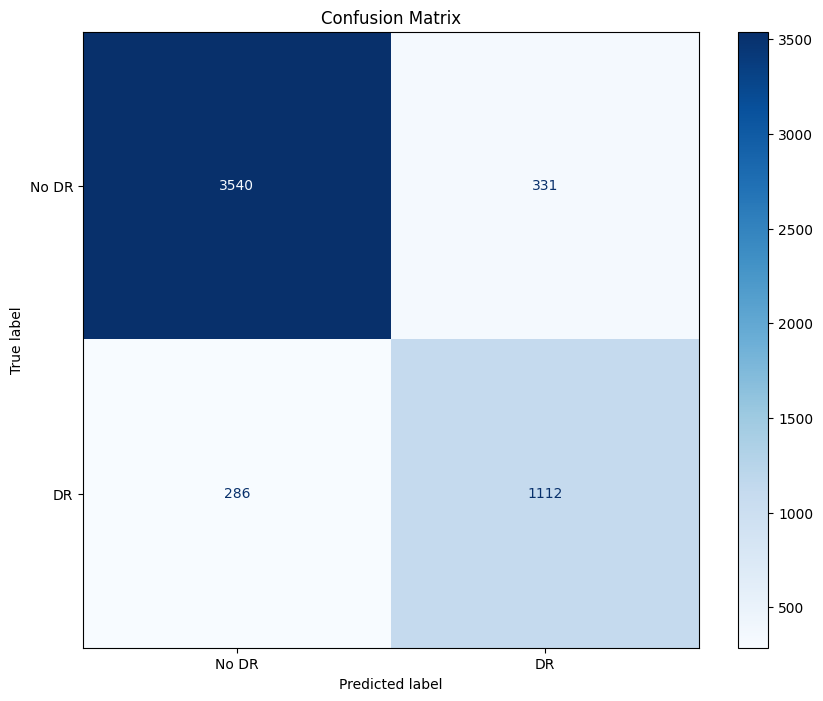


Classification Report:
              precision    recall  f1-score   support

       No DR       0.93      0.91      0.92      3871
          DR       0.77      0.80      0.78      1398

    accuracy                           0.88      5269
   macro avg       0.85      0.85      0.85      5269
weighted avg       0.88      0.88      0.88      5269



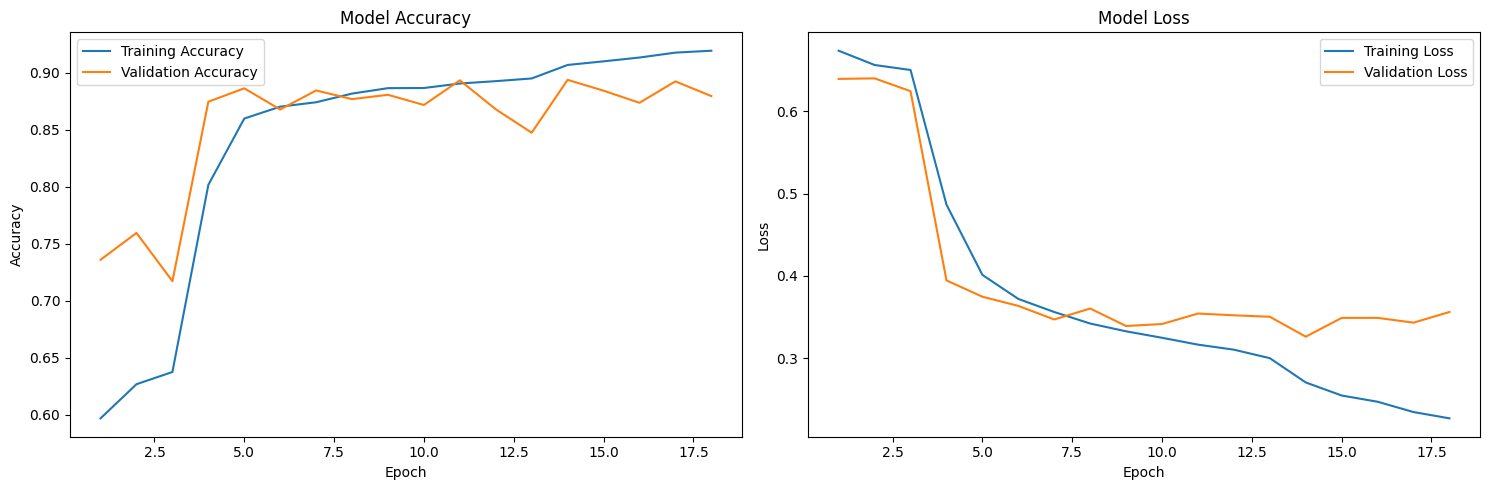


Calculating ROC and AUC...


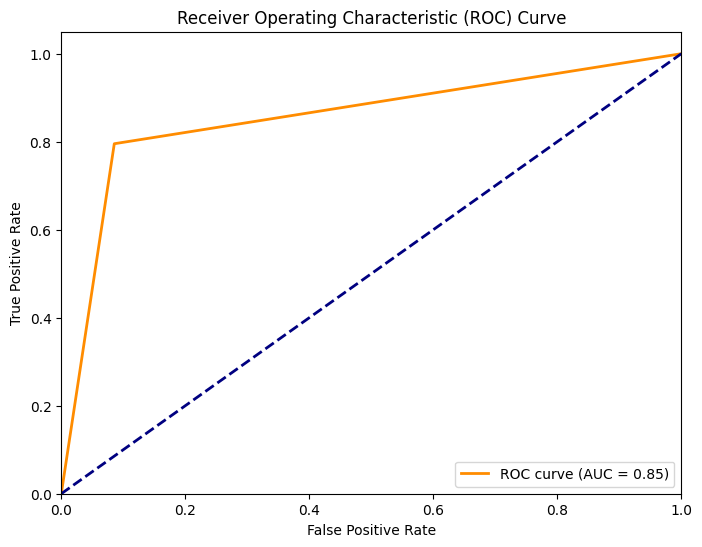

AUC: 0.8550
----------------------------------
ReduceLrOnPlateau history


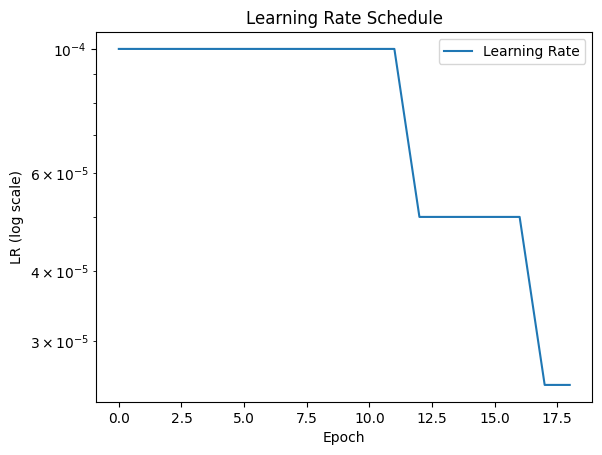

In [ ]:

#define the optimizer
optimizer = define_optimizer()


#defines our loss function
#here we can pass in the class weights
criterion = nn.CrossEntropyLoss(weight=weighted_class)

"""
This decays the learning rate to N amount of the previous value per N epochs which is whatever its set to.
"""
scheduler = lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
Num_EPOCHS = 40

#call the main function which calls train,val and test respectively.
main(model, scheduler=scheduler, EPOCHS=Num_EPOCHS,
     train_dataloader=train_loader, use_val_dataloader=True,
     optimizer=optimizer, criterion=criterion,model_name='InceptionV3',
     val_dataloader=val_loader)

# DenseNet121


In [ ]:
#DenseNet121 architecture

model = torchvision.models.densenet121(weights=weights['DenseNet121']).to(device)
print(f"the number of trainable parameters are :{sum(param.numel() for param in model.parameters() if param.requires_grad)}" )
print(model)
#freeze all parameters
for parameters in model.parameters():
    parameters.requires_grad=False



#adjust the head
model.classifier = nn.Sequential(
    #after the Avg pooling layer the dimensions of feature maps are reduced to a 1d vector which is already implemented in the densenet
    nn.Dropout(p=0.5),
    nn.Linear(model.classifier.in_features, out_features=2048),
    nn.ReLU(),
    nn.Dropout(p=0.3),
    nn.Linear(in_features = 2048, out_features=2)).to(device)

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth
100%|██████████| 30.8M/30.8M [00:00<00:00, 70.5MB/s]


the number of trainable parameters are :7978856
DenseNet(
  (features): Sequential(
    (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu0): ReLU(inplace=True)
    (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): _DenseBlock(
      (denselayer1): _DenseLayer(
        (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (denselayer2): _DenseLayer(
        (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affi

In [ ]:
#model after modification of classifier
print(model)

DenseNet(
  (features): Sequential(
    (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu0): ReLU(inplace=True)
    (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): _DenseBlock(
      (denselayer1): _DenseLayer(
        (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (denselayer2): _DenseLayer(
        (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu

Epoch:   0%|          | 0/40 [00:00<?, ?it/s]

about to leave train


Epoch:   2%|▎         | 1/40 [17:07<11:07:47, 1027.38s/it]

Learning rate at epoch 1: 0.000100
Epoch 1/40: Train Loss: 0.6659, Train Acc: 0.6137, Training time: 15.86 min, Val Loss: 0.6164, Val Acc: 0.7166, Val time: 1.13 min
about to leave train


Epoch:   5%|▌         | 2/40 [34:12<10:49:45, 1025.93s/it]

...

Epoch:  57%|█████▊    | 23/40 [6:33:16<4:51:10, 1027.69s/it]

Learning rate at epoch 23: 0.000025
loss didnt improve from best recorded loss so far : 23/40
Epoch 23/40: Train Loss: 0.2110, Train Acc: 0.9263, Training time: 16.13 min, Val Loss: 0.3631, Val Acc: 0.8825, Val time: 1.11 min
about to leave train


Epoch:  57%|█████▊    | 23/40 [6:50:11<5:03:10, 1070.05s/it]

Learning rate at epoch 24: 0.000025
loss didnt improve from best recorded loss so far : 24/40
Early stopping triggered!!!
-------------------------------------------------------------------
running it through the test set


test_loss : 0.3280
test accuracy : 0.8920


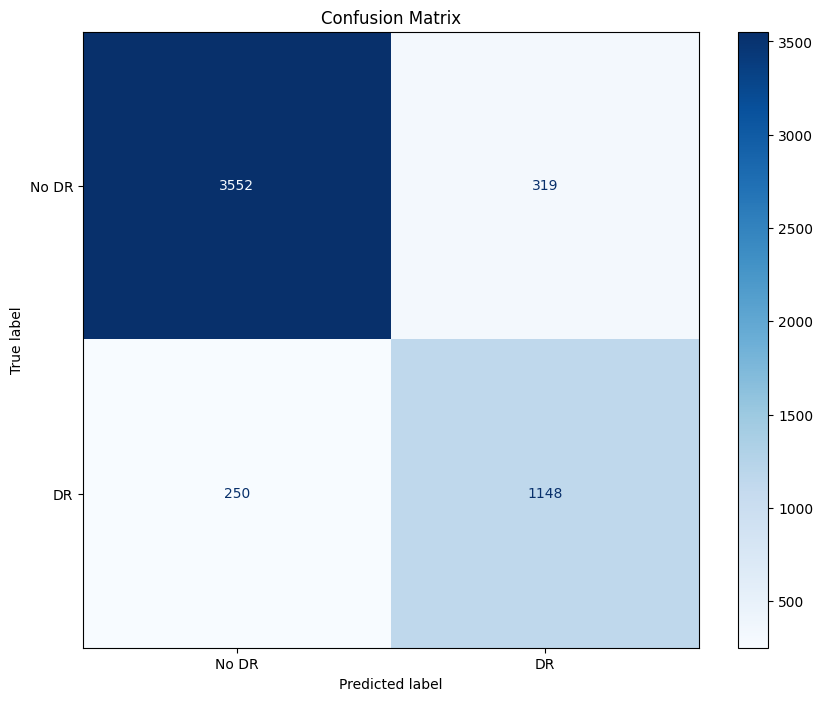


Classification Report:
              precision    recall  f1-score   support

       No DR       0.93      0.92      0.93      3871
          DR       0.78      0.82      0.80      1398

    accuracy                           0.89      5269
   macro avg       0.86      0.87      0.86      5269
weighted avg       0.89      0.89      0.89      5269



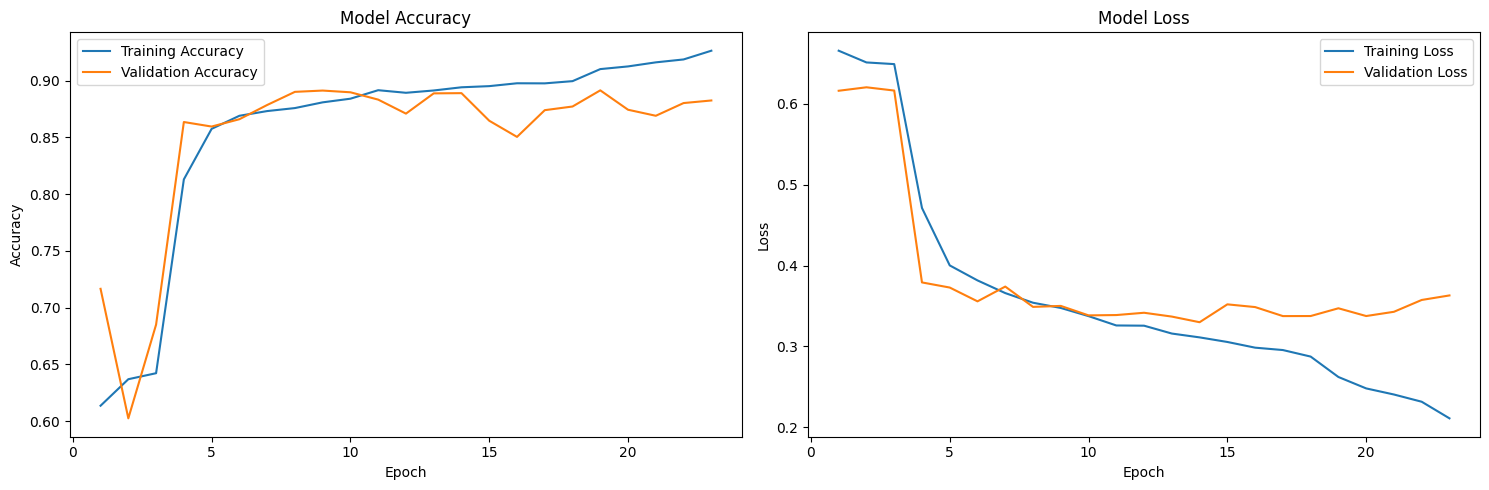


Calculating ROC and AUC...


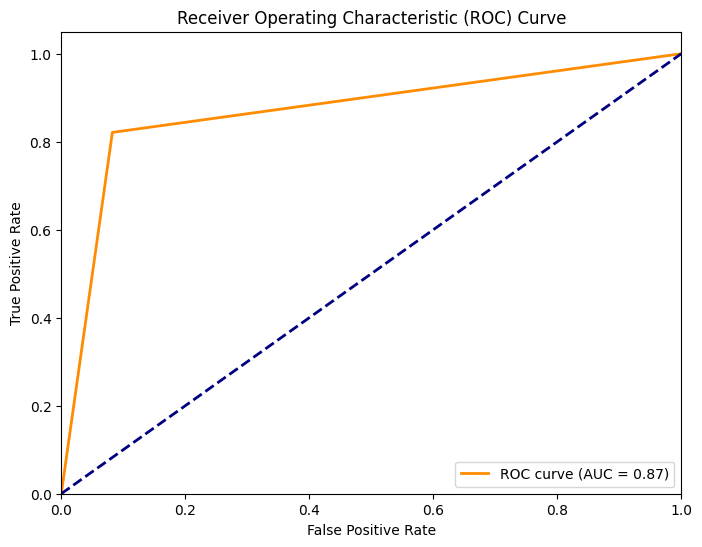

AUC: 0.8694
----------------------------------
ReduceLrOnPlateau history


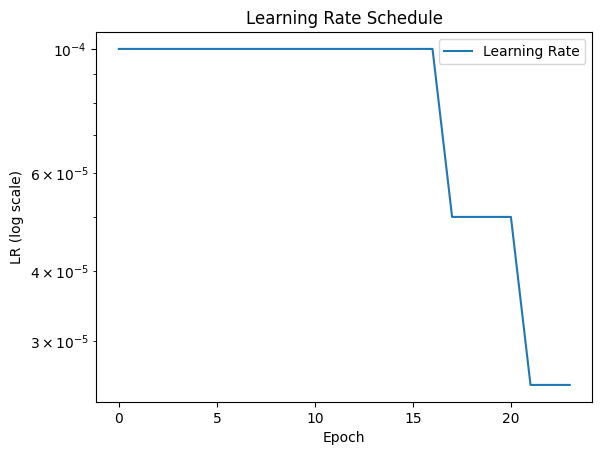

In [ ]:

#define the optimizer
optimizer = define_optimizer()


#defines our loss function
#here we can pass in the class weights
criterion = nn.CrossEntropyLoss(weight=weighted_class)

"""
This decays the learning rate to N amount of the previous value per N epochs which is whatever its set to.
"""
scheduler = lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
Num_EPOCHS = 40

#call the main function which calls train,val and test respectively.
main(model, scheduler=scheduler, EPOCHS=Num_EPOCHS,
     train_dataloader=train_loader, use_val_dataloader=True,
     optimizer=optimizer, criterion=criterion,model_name='DenseNet121',
     val_dataloader=val_loader)

Below represents something i'd be interested in doing,

Essentially comparing full fine tuning versus shallow tuning under consistent conditions. 

This allows us to understand whether the pretrained weights can be used for our task without optimizing their parameters. This saves Computational Power and Time.

# Shallow tuning

Shallow tuning is where we only tune or unfreeze the last few convolutional blocks, this way we allow the pretrained models to extract the generic features in the earlier layers and thereby we fine tune the last few blocks to extract features within our domain.


The way we will shallow tune is by unfreezing the last 4 convolutional blocks of each model after training the classifier head for N epochs.


While architectures differ substantially in their building blocks and connectivity patterns, our experimental design maintains consistency by fine-tuning approximately the final 30% of each network's depth.

#Shallow tuning with resnet50

In [ ]:
#lets look at the few blocks of the resnet 50 model

model = torchvision.models.resnet50(weights=weights['resnet50']).to(device)

#we will set the all layers to be frozen before unfreezing the last 30%
for parameters in model.parameters():
    parameters.requires_grad = False


model.fc = nn.Sequential(
    #after the Avg pooling layer the dimensions of feature maps are reduced to a 1d vector
    nn.Dropout(p=0.5),
    nn.Linear(model.fc.in_features, out_features=2048),
    nn.ReLU(),
    nn.Dropout(p=0.3),
    nn.Linear(in_features = 2048, out_features=2)).to(device)


optimizer = define_optimizer()
scheduler = lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
Num_EPOCHS = 40
criterion = nn.CrossEntropyLoss(weight=weighted_class)
main(
    model=model,
    scheduler=scheduler,
    EPOCHS=Num_EPOCHS,
    train_dataloader=train_loader,
    use_val_dataloader=True,
    optimizer=optimizer,
    criterion=criterion,
    model_name='resnet50',
    val_dataloader=val_loader,
    tuning_strategy='shallow'

)


"""
# 4. Verify initial state (only classifier should be trainable)
print("===== INITIAL STATE =====")
print_trainable_layers(model)

# 5. Count trainable parameters before unfreezing
initial_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())
print(f"Initially trainable parameters: {initial_trainable:,}/{total_params:,} ({initial_trainable/total_params:.2%})")

# 6. Call unfreeze_blocks
print("\n===== AFTER UNFREEZING BLOCKS =====")
unfreeze_blocks(model, 'resnet50')

# 7. Verify final state (classifier + unfrozen blocks should be trainable)
print("\n===== FINAL TRAINABLE LAYERS =====")
print_trainable_layers(model)

# 8. Count trainable parameters after unfreezing
final_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Final trainable parameters: {final_trainable:,}/{total_params:,} ({final_trainable/total_params:.2%})")
print(f"Change: {final_trainable - initial_trainable:,} additional parameters unfrozen")


"""


Epoch:   0%|          | 0/40 [00:00<?, ?it/s]

about to leave train


Epoch:   2%|▎         | 1/40 [17:04<11:05:38, 1024.06s/it]

Learning rate at epoch 1: 0.000100
Epoch 1/40: Train Loss: 0.6338, Train Acc: 0.6573, Training time: 15.94 min, Val Loss: 0.5978, Val Acc: 0.7510, Val time: 1.12 min
about to leave train


Epoch:   5%|▌         | 2/40 [34:19<10:52:40, 1030.54s/it]

...

Learning rate at epoch 8: 0.000100
Epoch 8/40: Train Loss: 0.3966, Train Acc: 0.8507, Training time: 16.18 min, Val Loss: 0.4186, Val Acc: 0.8336, Val time: 1.12 min
about to leave train


Epoch:  22%|██▎       | 9/40 [2:34:21<8:52:32, 1030.72s/it]

Learning rate at epoch 9: 0.000100
Epoch 9/40: Train Loss: 0.3865, Train Acc: 0.8555, Training time: 16.06 min, Val Loss: 0.4095, Val Acc: 0.8379, Val time: 1.12 min
about to leave train


Epoch:  25%|██▌       | 10/40 [2:51:28<8:34:49, 1029.64s/it]

Learning rate at epoch 10: 0.000100
Epoch 10/40: Train Loss: 0.3745, Train Acc: 0.8619, Training time: 15.98 min, Val Loss: 0.4072, Val Acc: 0.8320, Val time: 1.12 min
